In [1]:
# install bertopic
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 4.8 MB/s eta 0:00:00


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.6 MB/s eta 0:00:00


In [3]:
from bertopic import BERTopic
import gensim.corpora as corpora
from pprint import pprint
import nltk
import pandas as pd
import gensim.corpora as corpora
from gensim.models.ldamodel import LdaModel
from nltk.corpus import stopwords
import spacy
import numpy as np
import gensim
from gensim.models.coherencemodel import CoherenceModel
from gensim.utils import simple_preprocess
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from matplotlib import pyplot as plt
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic.vectorizers import ClassTfidfTransformer
from gensim.corpora import Dictionary


nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

### **BERTopic analysis for English data**

In [4]:
# input the English data
df_English = pd.read_csv("/content/lifelong learning_English.csv")


# delate the NA abstracts
df_English.dropna(subset=['Abstract'], inplace=True)
df_English['Abstract'] = df_English['Abstract'].astype(str)   # transfer 'Abstract' into strings

# define a function for tokenization
def count_tokens(text):
  return len(nltk.word_tokenize(text))

# calculate the token numbers in 'Abstract'
df_English['Token Count'] = df_English['Abstract'].apply(count_tokens)

# filter datapoints where the token numbers are less than 24
df = df_English[df_English['Token Count'] >= 24]

# remove the created 'Token Count' column
df = df.drop(columns=['Token Count'])
df.head(5)

,Publication Type,Authors,Book Authors,Book Editors,Author Full Names,Book Author Full Names,Article Title,Source Title,Book Series Title,Abstract,Publication Year,Volume,Issue,Start Page,End Page
0,J,"Schrock, JW; Cydulka, RK",NaN,NaN,"Schrock, Jon W.; Cydulka, Rita K.",NaN,Lifelong learning,EMERGENCY MEDICINE CLINICS OF NORTH AMERICA,NaN,Early American physician education lacked qual...,2006,24.0,3,785,+
1,J,"BELANGER, P",NaN,NaN,"BELANGER, P",NaN,LIFELONG LEARNING - THE DIALECTICS OF LIFELONG...,INTERNATIONAL REVIEW OF EDUCATION,NaN,This article examines the emergence of differe...,1994,40.0,3-5,353,381
2,C,"Bostan, CG",NaN,"Vasile, C","Bostan, Carmen-Gabriela",NaN,Emergencies in lifelong learning,ADULT EDUCATION IN UNIVERSITIES: LOCAL AND REG...,Procedia Social and Behavioral Sciences,"25 years after the revolution, there are more ...",2014,142.0,NaN,268,273
3,B,"Al Mosawi, AJ",NaN,"Caltone, MP","Al Mosawi, Aamir Jalal",NaN,LIFELONG LEARNING FOR PHYSICIANS,HANDBOOK OF LIFELONG LEARNING DEVELOPMENTS,Education in a Competitive and Globalizing World,Introduction The primary concept of lifelong l...,2010,NaN,NaN,213,237
4,J,"Cuffy, V; Tribe, J; Airey, D",NaN,NaN,"Cuffy, Violet; Tribe, John; Airey, David",NaN,LIFELONG LEARNING FOR TOURISM,ANNALS OF TOURISM RESEARCH,NaN,This paper examines the provision of education...,2012,39.0,3,1402,1424


In [5]:
# remove stopwords

# import the stopwords
stop_words = set(stopwords.words('english'))
stop_words.add('lifelong')
stop_words.add('education')
stop_words.add('learn')
stop_words.add('learning')
# define a function to remove stopwords
def remove_stopwords(abstract):
  # convert all strings into lowercases
  abstract_lower = abstract.lower()

  # tokenization
  words = nltk.word_tokenize(abstract_lower)

  # remove stopwords
  text_removed = [word for word in words if word not in stop_words]

  # return the processed texts
  return text_removed

processed_abstract_list = []
for each_abstract in df['Abstract']:
  processed_abstract = remove_stopwords(each_abstract)
  processed_abstract_list.append(processed_abstract)

processed_stringformat = [' '.join(map(str, lst)) for lst in processed_abstract_list]

In [6]:
# Load the English model
nlp = spacy.load('en_core_web_sm')
# a new list for lemmatized sentences
lemmatized_sentence = []
for each_sentence in processed_stringformat:
  lemmatized_words_list = []
  each_doc = nlp(each_sentence)
  for token in each_doc:
    if token.pos_ in ('NOUN', 'ADV', 'PROPN', 'VERB', 'ADJ'):
      lemmatized_words_list.append(token.lemma_)
  lemmatized_sentence.append(' '.join(lemmatized_words_list))

In [7]:
len(lemmatized_sentence)

# In total, we have 979 rows of data.

1054

In [12]:
# Extract embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Reduce dimensionality
umap_model = UMAP(n_neighbors=100, n_components=10, min_dist=0.0, metric='cosine')

# Cluster reduced embeddings
hdbscan_model = HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# we add this to remove stopwords and set the N-gram range
vectorizer_model = CountVectorizer(ngram_range=(1, 3), stop_words="english")

# create topic representation
ctfidf_model = ClassTfidfTransformer()


In [16]:
# prepare tokenized documents
tokenized_docs = [doc.split() for doc in lemmatized_sentence]
dictionary = corpora.Dictionary(tokenized_docs)


min_topic_size=  2 | topics=119 | outliers=36.53% | c_v=0.4745
min_topic_size=  3 | topics= 58 | outliers=42.98% | c_v=0.4699
min_topic_size=  4 | topics= 33 | outliers=47.25% | c_v=0.4609
min_topic_size=  5 | topics= 23 | outliers=52.28% | c_v=0.4808
min_topic_size=  6 | topics= 16 | outliers=48.39% | c_v=0.4393
min_topic_size=  7 | topics= 12 | outliers=42.88% | c_v=0.4967
min_topic_size=  8 | topics= 12 | outliers=39.18% | c_v=0.4876
min_topic_size=  9 | topics= 13 | outliers=54.17% | c_v=0.5043
min_topic_size= 10 | topics=  3 | outliers=6.26% | c_v=0.5544
min_topic_size= 11 | topics= 10 | outliers=46.87% | c_v=0.4905
min_topic_size= 12 | topics=  3 | outliers=5.12% | c_v=0.5428
min_topic_size= 13 | topics=  2 | outliers=2.37% | c_v=0.4830
min_topic_size= 14 | topics=  2 | outliers=6.74% | c_v=0.4830
min_topic_size= 15 | topics=  2 | outliers=5.60% | c_v=0.4927
min_topic_size= 16 | topics=  2 | outliers=2.66% | c_v=0.4830
min_topic_size= 17 | topics=  2 | outliers=4.74% | c_v=0.4830

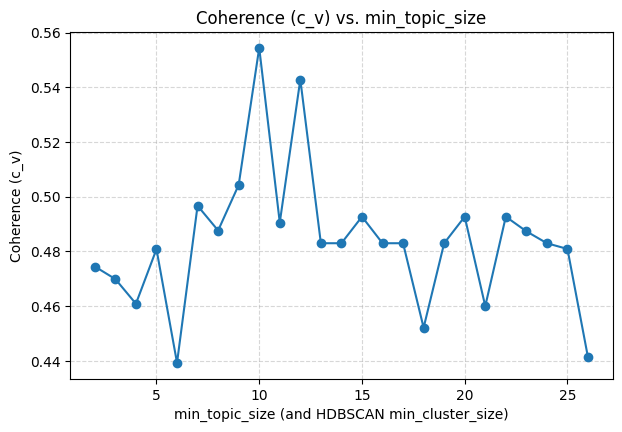

In [ ]:

def get_topic_words(model, top_n=20):
    topics = model.get_topics()
    return [[w for w, _ in topics[t][:top_n]] for t in topics if t != -1]

def coherence_cv(model, tokenized_docs, dictionary, top_n=20):
    tw = get_topic_words(model, top_n=top_n)
    if not tw:
        return np.nan
    cm = CoherenceModel(
        topics=tw,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return cm.get_coherence()

# 2) sweep min_topic_size
results = {
    "min_topic_size": [],
    "n_topics": [],
    "outlier_rate": [],
    "coherence_cv": []
}

for m in [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26]:

    umap_model = UMAP(n_neighbors=100, n_components=10, min_dist=0.0, metric='cosine')

    hdbscan_tuned = HDBSCAN(
        min_cluster_size=m,
        metric='euclidean',
        cluster_selection_method='eom',
        prediction_data=True
    )

    topic_model_m = BERTopic(
        language='English',
        min_topic_size=m,
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_tuned,
        vectorizer_model=vectorizer_model,
        ctfidf_model=ctfidf_model,
        verbose=False,
    )

    topics, _ = topic_model_m.fit_transform(lemmatized_sentence)

    # Metrics
    n_topics = len(set(t for t in topics if t != -1))
    outlier_rate = float(np.mean(np.array(topics) == -1))
    c_v = coherence_cv(topic_model_m, tokenized_docs, dictionary, top_n=20)

    results["min_topic_size"].append(m)
    results["n_topics"].append(n_topics)
    results["outlier_rate"].append(outlier_rate)
    results["coherence_cv"].append(c_v)
    print(f"min_topic_size={m:>3} | topics={n_topics:>3} | outliers={outlier_rate:>5.2%} | c_v={c_v:.4f}")

# 3) Inspect results
for m, k, o, cv in zip(results["min_topic_size"], results["n_topics"], results["outlier_rate"], results["coherence_cv"]):
    print(f"min_topic_size={m:>3} | topics={k:>3} | outliers={o:>5.2%} | c_v={cv:.4f}")


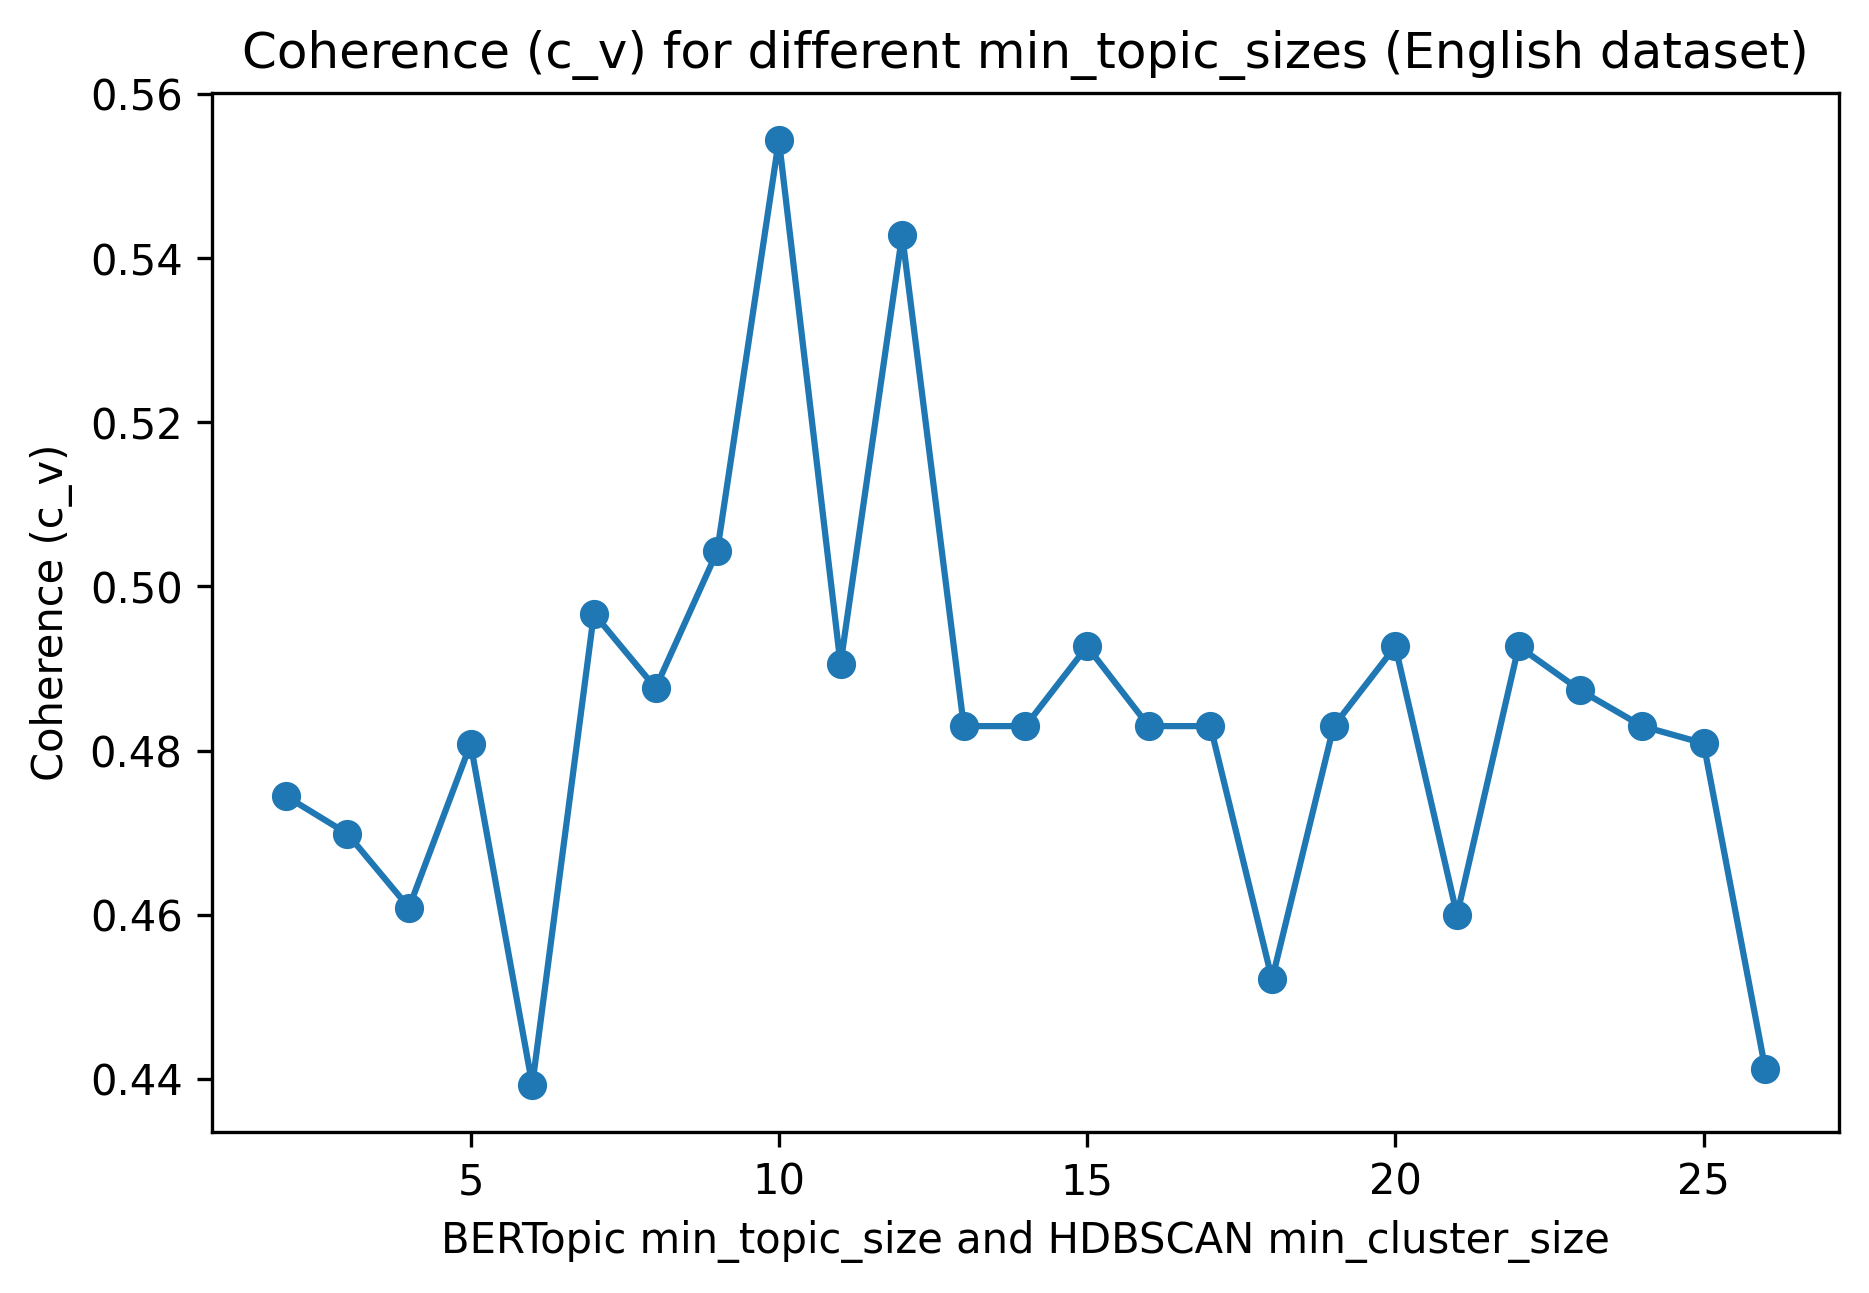

In [ ]:
# Plot coherence vs min_topic_size
plt.figure(figsize=(7,4.5), dpi=300)
plt.plot(results["min_topic_size"], results["coherence_cv"], marker='o')
plt.title('Coherence (c_v) for different min_topic_sizes (English dataset)')
plt.xlabel('BERTopic min_topic_size and HDBSCAN min_cluster_size')
plt.ylabel('Coherence (c_v)')
plt.grid(False)
plt.show()

### **LDA analysis for English data**

In [ ]:
# from the sentence to sublists containing words

def sent_to_words(sentences):
    for sent in sentences:
        sent = gensim.utils.simple_preprocess(str(sent), deacc=True)
        yield(sent)

In [ ]:
# build the N-gram models
bigram = gensim.models.Phrases(lemmatized_sentence, min_count=5, threshold=30)
trigram = gensim.models.Phrases(bigram[lemmatized_sentence], threshold=30)
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

In [ ]:
def process_words(texts, stop_words=stop_words, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """Remove Stopwords, Form Bigrams, Trigrams and Lemmatization"""
    texts = [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]
    texts = [bigram_mod[doc] for doc in texts]
    texts = [trigram_mod[bigram_mod[doc]] for doc in texts]
    texts_out = []
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])
    for sent in texts:
        doc = nlp(" ".join(sent))
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    # remove stopwords once more after lemmatization
    texts_out = [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts_out]
    return texts_out

In [ ]:
lda_data = lemmatized_sentence
data_words = list(sent_to_words(lda_data))
print(data_words[:1])

[['early', 'american', 'physician', 'lack', 'quality', 'consistency', 'poorly', 'fund', 'institution', 'weak', 'curriculum', 'little', 'patient', 'contact', 'graduation', 'train', 'early', 'doctor', 'advent', 'twentieth', 'century', 'reformation', 'medical', 'take', 'place', 'create', 'foundation', 'modem', 'american', 'medical', 'system', 'importance', 'physician', 'increase', 'lead', 'production', 'specialty', 'board', 'requirement', 'continue', 'medical', 'culminate', 'continuous', 'certification', 'process', 'require', 'specialty', 'include', 'american', 'board', 'emergency', 'medicine', 'utility', 'continue', 'medical', 'question', 'technological', 'advance', 'internet', 'improve', 'technique', 'help', 'physician', 'practice', 'modem', 'medicine', 'time', 'rapidly', 'expand', 'science']]


In [ ]:
processed_data = process_words(data_words)
processed_data[:1]

def filter_min_len(texts, min_len=2):
    return [t for t in texts if len(t) >= min_len]

processed_data = filter_min_len(processed_data, min_len=2)

# rebuild dictionary/corpus for coherence evaluation
id2word = corpora.Dictionary(processed_data)
corpus  = [id2word.doc2bow(t) for t in processed_data]

In [ ]:
K = 10

lda = gensim.models.ldamodel.LdaModel(corpus=corpus,
                    id2word=id2word,
                    num_topics=K,
                    random_state=100,
                    update_every=1,
                    chunksize=10,
                    passes=10,
                    alpha='symmetric',
                    iterations=1000,
                    per_word_topics=True)


# point estimates
cm = CoherenceModel(model=lda, texts=processed_data, dictionary=id2word, coherence='c_v')
coh_overall = cm.get_coherence()
coh_per_topic = cm.get_coherence_per_topic()
print(f"Overall c_v: {coh_overall:.4f}")
for i, c in enumerate(coh_per_topic):
    print(f"Topic {i:02d} c_v: {c:.4f}")


# 1) clean texts used for coherence
texts_all = filter_min_len(processed_data, 2)
id2word = corpora.Dictionary(texts_all)
id2word.filter_extremes(no_below=5, no_above=0.6)

# 2) topic word lists
TOP_N = 8
topics_words = []
for _, topic in lda.show_topics(num_topics=K, num_words=TOP_N, formatted=False):
    ws = [w for w, _ in topic if w in id2word.token2id]
    if len(ws) >= 2:
        topics_words.append(ws)

# 3) subsample-based CI
M = 100                     # subsample iterations
ratio = 0.8                 # 80% subsample
N = len(texts_all)
size = max(50, int(ratio * N))
rng = np.random.default_rng(42)

scores = []
for _ in range(M):
    idx = rng.choice(N, size=size, replace=False)
    subs = [texts_all[i] for i in idx]

    # larger window helps co-occurrence counts
    cm = CoherenceModel(
        topics=topics_words,
        texts=subs,
        dictionary=id2word,
        coherence='c_v',
        window_size=200
    )
    val = cm.get_coherence()
    if np.isfinite(val):
        scores.append(val)

scores = np.array(scores)
if len(scores) == 0:
    raise RuntimeError("All subsample coherence values were invalid. Increase window_size or reduce TOP_N.")
ci_low, ci_high = np.percentile(scores, [2.5, 97.5])
print(f"Subsample c_v mean: {scores.mean():.4f}, std: {scores.std(ddof=1):.4f}")
print(f"Subsample 95% CI: [{ci_low:.4f}, {ci_high:.4f}] (M={len(scores)})")

Overall c_v: 0.4586
Topic 00 c_v: 0.2033
Topic 01 c_v: 0.1851
Topic 02 c_v: 0.1574
Topic 03 c_v: 0.6925
Topic 04 c_v: 0.6925
Topic 05 c_v: 0.6925
Topic 06 c_v: 0.2903
Topic 07 c_v: 0.6925
Topic 08 c_v: 0.6925
Topic 09 c_v: 0.2873
Subsample c_v mean: 0.4552, std: 0.0129
Subsample 95% CI: [0.4284, 0.4749] (M=100)


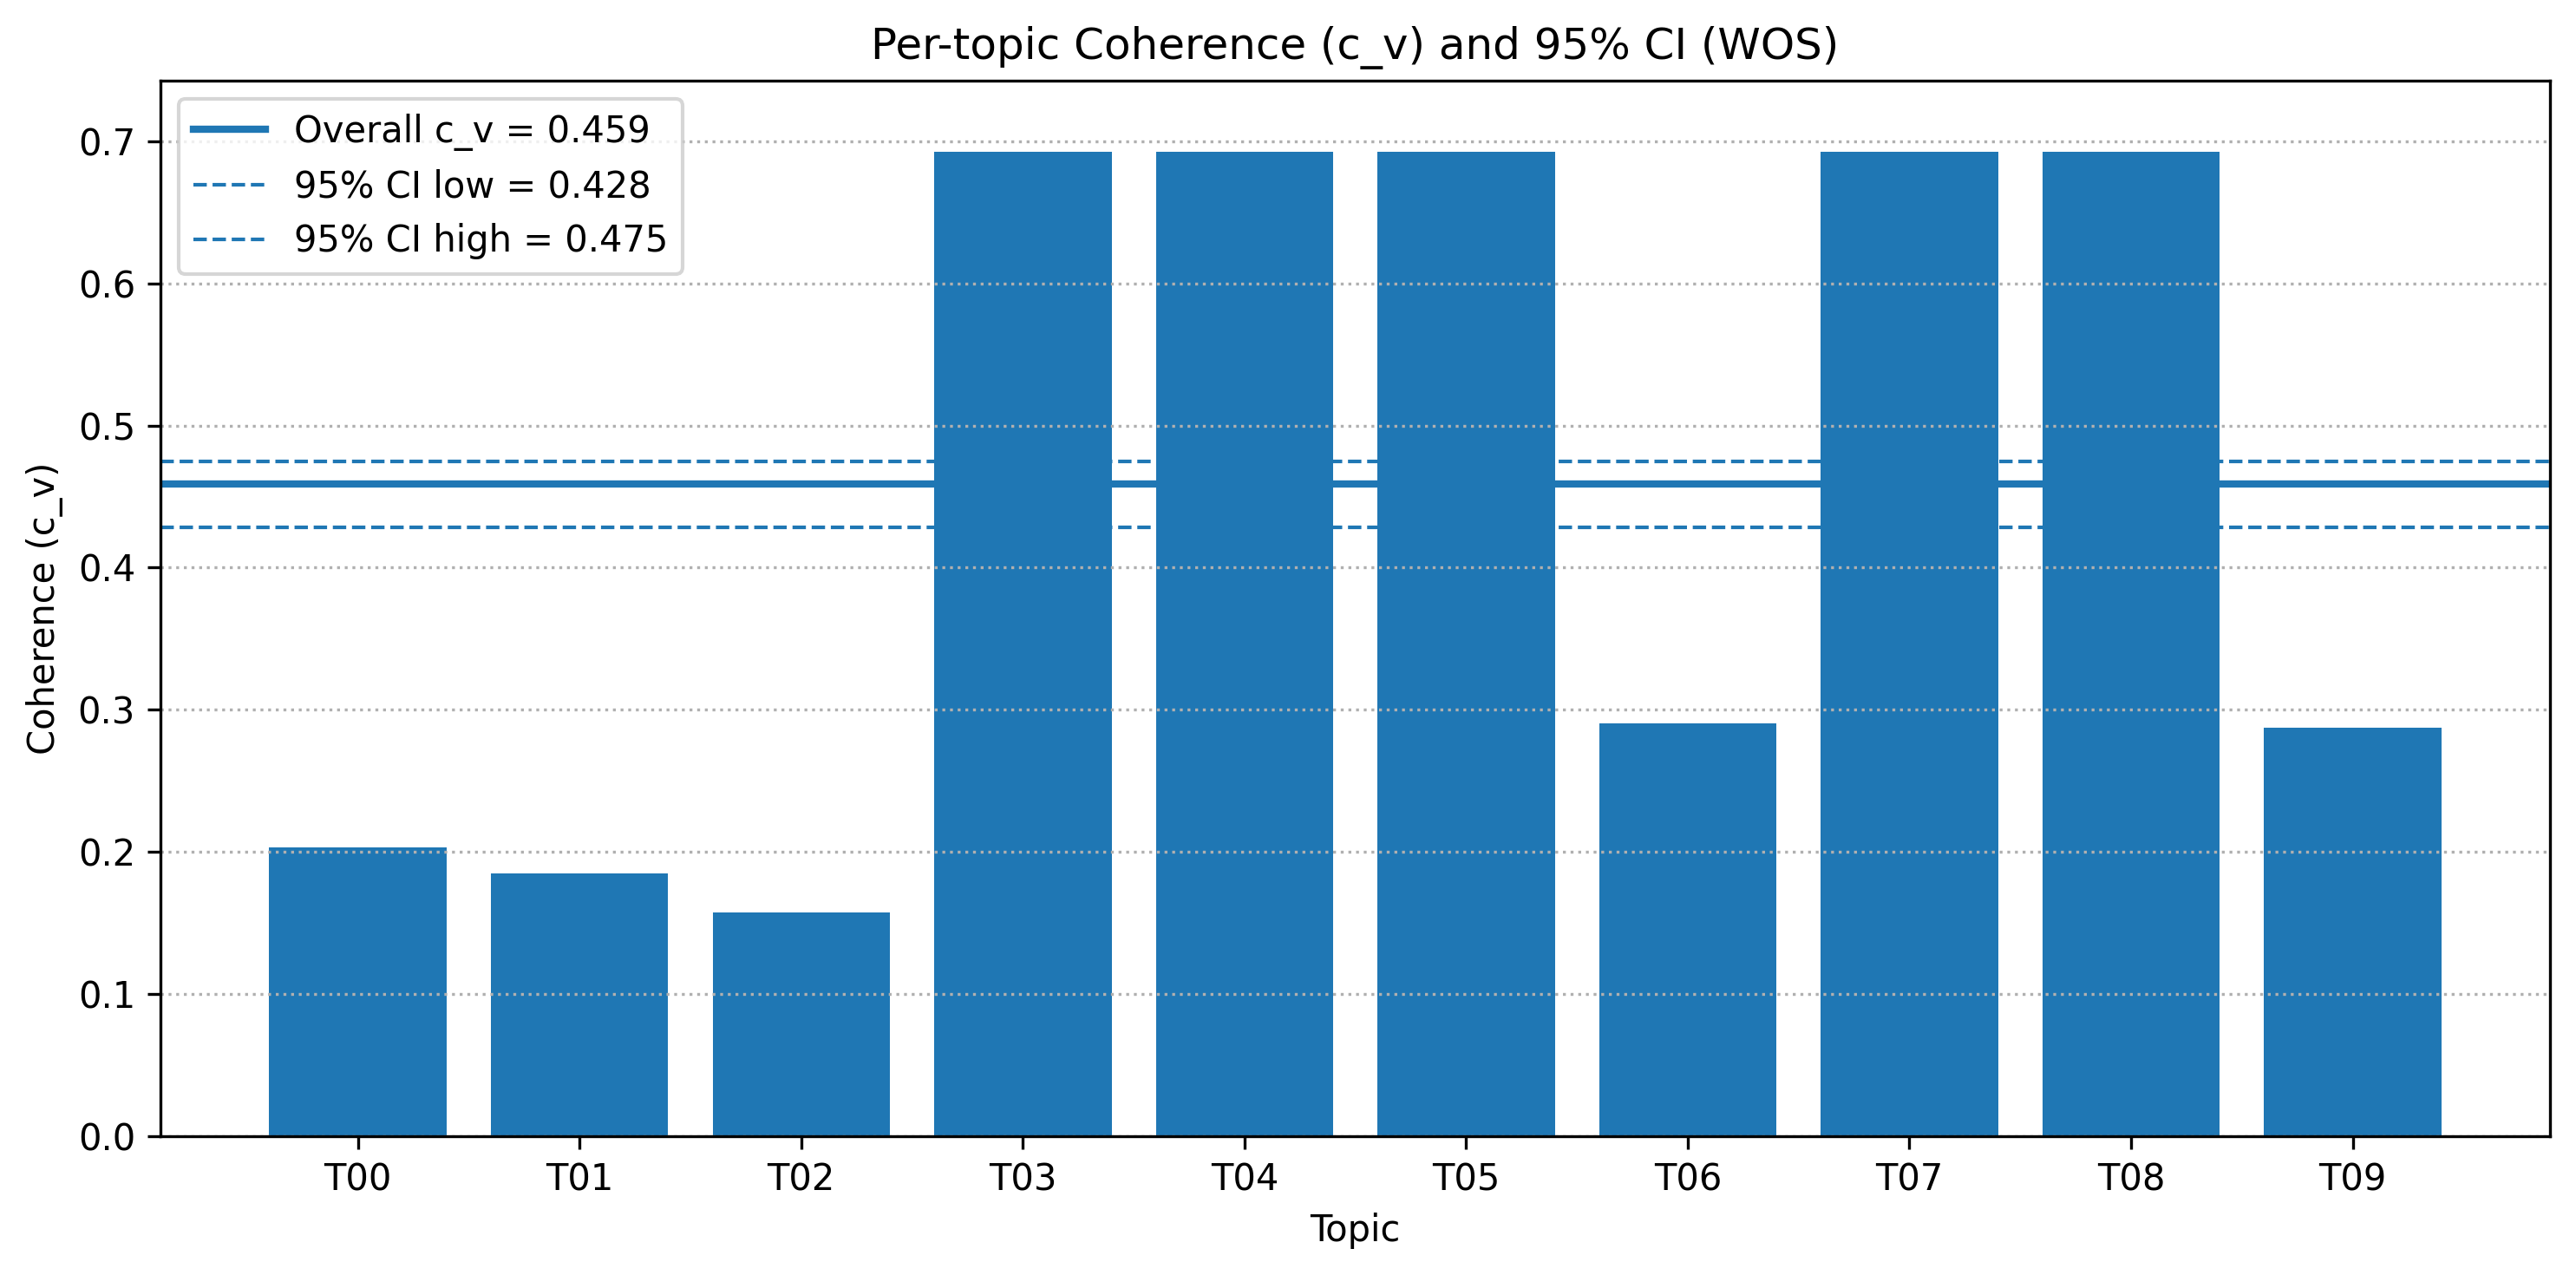

In [ ]:
# x-axis labels like T00, T01, ...
x = np.arange(K)
labels = [f"T{t:02d}" for t in x]
y = np.array(coh_per_topic)

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# bar chart of per-topic coherence
ax.bar(x, y)

# overall coherence line
ax.axhline(coh_overall, linestyle='-', linewidth=2, label=f"Overall c_v = {coh_overall:.3f}")

# 95% CI lines
ax.axhline(ci_low, linestyle='--', linewidth=1, label=f"95% CI low = {ci_low:.3f}")
ax.axhline(ci_high, linestyle='--', linewidth=1, label=f"95% CI high = {ci_high:.3f}")

# niceties
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("Coherence (c_v)")
ax.set_xlabel("Topic")
ax.set_title("Per-topic Coherence (c_v) and 95% CI (WOS)")
ax.set_ylim(0, max(0.7, y.max() + 0.05))  # small headroom
ax.legend(loc="best")
ax.grid(axis='y', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()
